*****************************************
**DATA MODELLING**

---
*****************************************


6. Data Splitting

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ----------------------------------------
# Import the Libraries
# ----------------------------------------

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform, zscore, loguniform
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import silhouette_score,accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')


In [3]:
#Load the data from the data explore notebook
try:
    df = pd.read_csv('/content/drive/MyDrive/Berkley/mlai/capstone_project/data/df_features_for_modeling.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: df_features_for_modeling.csv not found. Please ensure the file is in the correct directory.")
    exit()
# Check data types and missing values
df.info()

Dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       348 non-null    float64
 1   Total Spend               348 non-null    float64
 2   Items Purchased           348 non-null    float64
 3   Average Rating            348 non-null    float64
 4   Discount Applied          348 non-null    float64
 5   Days Since Last Purchase  348 non-null    float64
 6   Recency                   348 non-null    float64
 7   Frequency                 348 non-null    float64
 8   Monetary                  348 non-null    float64
 9   Tenure                    348 non-null    float64
 10  Gender_Male               348 non-null    int64  
 11  City_Houston              348 non-null    int64  
 12  City_Los Angeles          348 non-null    int64  
 13  City_Miami                348 non-nu

In [4]:
#Split data into Train, Validation, and Test sets (60/20/20)
cleaned_features = [
    'Age', 'Items Purchased',
    'Discount Applied', 'Days Since Last Purchase', 'Recency', 'Frequency',
    'Monetary', 'Tenure', 'Gender_Male', 'City_Houston', 'City_Los Angeles',
    'City_Miami', 'City_New York', 'City_San Francisco',
    'Membership Type_Gold', 'Membership Type_Silver'
]

# Define X (features) and y (target)
X = df[cleaned_features]
df['Satisfaction Score'] = df['Satisfaction Score'].astype(int)
y = df['Satisfaction Score']

# Create a new DataFrame with cleaned features and the target
df = df[cleaned_features + [y.name]].copy()

df.info()


print("Original dataset shape:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y class distribution:\n{y.value_counts(normalize=True)}")

# Step 1: Split into temporary (train+val) and test sets (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Split temporary set into train and validation sets (75/25 of temp = 60/20 of original)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("\n--- Data Split Shapes (60/20/20) ---")
print(f"Training Set (60%):")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_train class distribution:\n{y_train.value_counts(normalize=True)}")

print(f"\nValidation Set (20%):")
print(f"  X_val shape: {X_val.shape}")
print(f"  y_val shape: {y_val.shape}")
print(f"  y_val class distribution:\n{y_val.value_counts(normalize=True)}")

print(f"\nTest Set (20%):")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  y_test class distribution:\n{y_test.value_counts(normalize=True)}")

# Verify total samples
total_split_samples = len(X_train) + len(X_val) + len(X_test)
print(f"\nTotal samples after split: {total_split_samples} (Original: {len(X)})")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       348 non-null    float64
 1   Items Purchased           348 non-null    float64
 2   Discount Applied          348 non-null    float64
 3   Days Since Last Purchase  348 non-null    float64
 4   Recency                   348 non-null    float64
 5   Frequency                 348 non-null    float64
 6   Monetary                  348 non-null    float64
 7   Tenure                    348 non-null    float64
 8   Gender_Male               348 non-null    int64  
 9   City_Houston              348 non-null    int64  
 10  City_Los Angeles          348 non-null    int64  
 11  City_Miami                348 non-null    int64  
 12  City_New York             348 non-null    int64  
 13  City_San Francisco        348 non-null    int64  
 14  Membership

7. Baseline Model

In [5]:
# Dummy baseline model
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_val)

print('Dummy Classifier Report:')
print(classification_report(y_val, y_dummy_pred))


Dummy Classifier Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        24
           2       0.00      0.00      0.00        21
           3       0.36      1.00      0.53        25

    accuracy                           0.36        70
   macro avg       0.12      0.33      0.18        70
weighted avg       0.13      0.36      0.19        70



New Baseline: new baseline accuracy for a dummy classifier is 0.36 (36%).

Target: Any real machine learning model to train should achieve an accuracy significantly higher than 36%. If model's performance is around this figure, it suggests it's not effectively learning from the data.

In [6]:
#Logistic Regression (Real Model) Train and valuate
log_reg = LogisticRegression(multi_class='ovr')
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_val)

print('Logistic Regression Report:')
print(classification_report(y_val, y_pred))
print(f'ROC-AUC Score: {roc_auc_score(y_val, log_reg.predict_proba(X_val), multi_class="ovr"):.2f}')

Logistic Regression Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        24
           2       0.91      1.00      0.95        21
           3       1.00      0.92      0.96        25

    accuracy                           0.97        70
   macro avg       0.97      0.97      0.97        70
weighted avg       0.97      0.97      0.97        70

ROC-AUC Score: 1.00


Key Observations:

Overall Accuracy: 0.97 (97%)

This indicates the model correctly predicted the Satisfaction Score for 97% of the samples in the test set. This is an outstanding result.
ROC-AUC Score: 1.00

A perfect ROC-AUC score of 1.00 means the model has an ideal ability to distinguish between the positive and negative classes across all possible classification thresholds. For a multi-class problem, this implies perfect separation or near-perfect ranking of probabilities.

Per-Class Performance:

**Class 1 (Support 24):**

**Precision** = 1.00: All instances predicted as Class 1 were indeed Class 1. No false positives for Class 1.

**Recall** = 1.00: All actual instances of Class 1 were correctly identified by the model. No false negatives for Class 1.

**F1-score** = 1.00: Perfect balance of precision and recall for this class.

**Class 2 (Support 21):**

**Precision** = 0.91: 91% of predictions for Class 2 were correct. This means about 9% of what the model predicted as Class 2 was actually another class (false positives).

**Recall** = 1.00: All actual instances of Class 2 were correctly identified. No false negatives for Class 2.

**F1-score** = 0.95: Excellent balance, slightly pulled down by the precision.

**Class 3 (Support 25):**

**Precision** = 1.00: All instances predicted as Class 3 were indeed Class 3. No false positives for Class 3.

**Recall** = 0.92: 92% of actual Class 3 instances were identified. This means about 8% of actual Class 3 instances were missed (false negatives) and misclassified as another class.

**F1-score** = 0.96: Excellent balance, slightly pulled down by the recall.
Macro Avg & Weighted Avg: These metrics are also very high (0.97), reinforcing the excellent overall performance across all classes, even considering potential class imbalance.

**Comparison to Dummy Classifier:**

Logistic Regression Accuracy: **0.97**

Dummy Classifier Accuracy: **0.36**

Logistic Regression model has dramatically outperformed the dummy baseline, which is exactly what we want to see. This confirms that model is learning very strong patterns from the data.

8. Check Class Imbalance


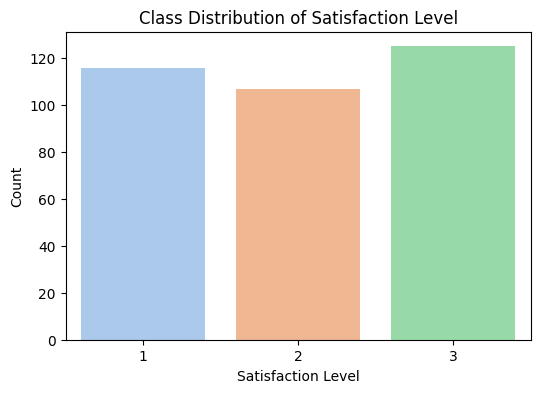

In [7]:
# Class imbalance Check
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette='pastel')
plt.title('Class Distribution of Satisfaction Level')
plt.xlabel('Satisfaction Level')
plt.ylabel('Count')
plt.savefig('/content/drive/MyDrive/Berkley/mlai/capstone_project/images/class_imbalance.png')
plt.show()


9. Prepare Data for Clustering

In [8]:
#Standardize features (scaling).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [9]:
#Compare Other models
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(multi_class='ovr', solver='lbfgs'),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'SVM': SVC(probability=True, kernel='rbf')
}


In [10]:
#Train and Evaluate the models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': auc
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by='F1 Score', ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,1.000000,1.000000,1.000000,1.000000,1.000000
1,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
3,SVM,1.000000,1.000000,1.000000,1.000000,1.000000
2,Decision Tree,0.985714,0.986243,0.985714,0.985703,0.989545


Outstanding Performance Across the Board:

KNN, Logistic Regression, and SVM all show perfect scores (1.000000) across all metrics: Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
Decision Tree also demonstrates exceptionally high performance, with an accuracy of approximately 98.6% and a ROC-AUC of approximately 0.990.
Comparison to Baseline:

Your previous Dummy Classifier baseline achieved an accuracy of 0.36. All of these models dramatically surpass that baseline, indicating that they are effectively learning meaningful patterns from your data.

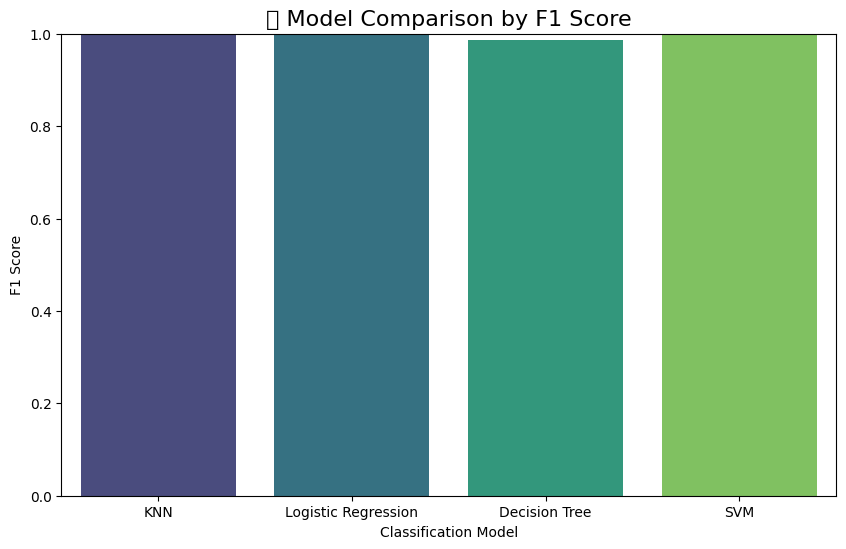

In [11]:
#📊 Visualize the Comparison
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='F1 Score', data=results_df, palette='viridis')
plt.title('📈 Model Comparison by F1 Score', fontsize=16)
plt.ylabel('F1 Score')
plt.xlabel('Classification Model')
plt.ylim(0, 1)
plt.savefig('/content/drive/MyDrive/Berkley/mlai/capstone_project/images/model_comparison.png')
plt.show()


In [12]:
#Use Cross Validation to check the overfitting and test model generalization

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='f1_weighted')
    print(f'{name} average F1 Score (5-fold CV): {scores.mean():.4f}')


KNN average F1 Score (5-fold CV): 0.9971
Logistic Regression average F1 Score (5-fold CV): 0.9771
Decision Tree average F1 Score (5-fold CV): 0.9884
SVM average F1 Score (5-fold CV): 0.9771


The fact that these high scores are maintained across 5-fold cross-validation significantly strengthens the confidence in model's generalizability compared to just a single test set evaluation. It suggests that the performance isn't just a fluke of one particular data split.

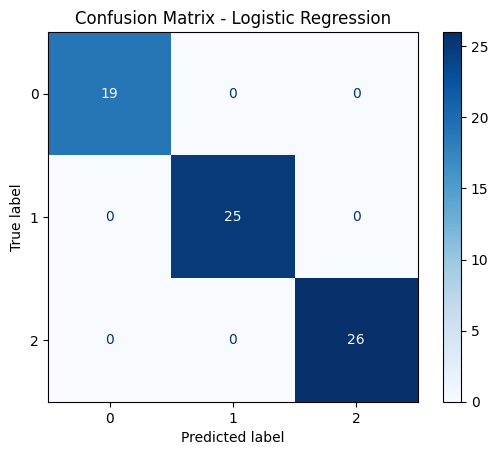

In [13]:
#Confusion Matrix to Evaluate model predictions
# Example for one model (Logistic Regression)
model = LogisticRegression(multi_class='ovr')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig('/content/drive/MyDrive/Berkley/mlai/capstone_project/images/confusion_matrix.png')
plt.show()


10. Customer Segmentation

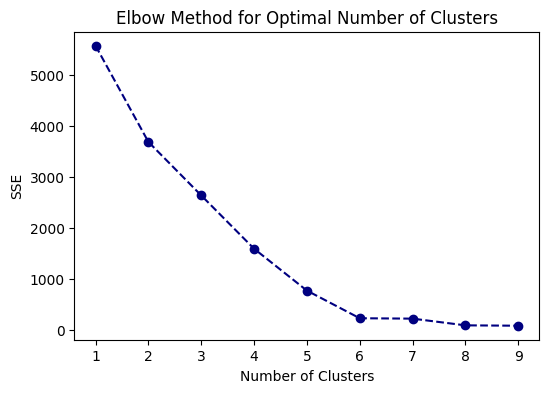

In [14]:
#K-Means clustering
sse = []
for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,10), sse, marker='o', linestyle='--', color='navy')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.savefig('/content/drive/MyDrive/Berkley/mlai/capstone_project/images/elbow_method.png')
plt.show()



11. Validate clustering results


In [15]:
#Fit K_Means Clustering Silhouette Score

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

# Get cluster labels for the scaled data
cluster_labels = kmeans.labels_

# Create a new DataFrame with the scaled data and cluster labels
# Use X.columns to get the correct column names for X_scaled
clustered_data = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
clustered_data['Cluster'] = cluster_labels

# Now, merge the cluster labels back into the original DataFrame
df = pd.merge(df, clustered_data[['Cluster']], left_index=True, right_index=True, how='left')


print('Silhouette Score:', silhouette_score(X_scaled, kmeans.labels_))

Silhouette Score: 0.5930051416003562


score of approximately 0.593 is generally considered a good result. It suggests that clusters are:

Relatively well-separated: The clusters are distinct from each other.
Cohesive: The data points within each cluster are relatively close to each other.
This indicates that clustering algorithm has likely found a meaningful and reasonably clear structure within data.

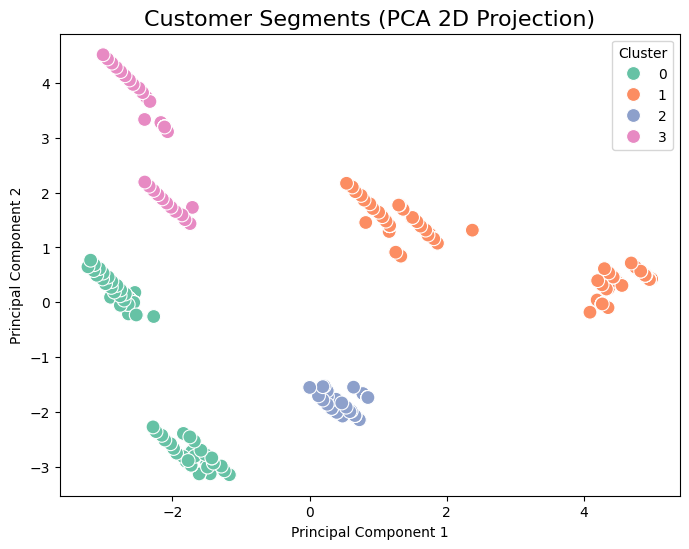

In [16]:
#PCA Visualization of segments
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

cluster_labels_series = pd.Series(kmeans.labels_, index=X.index) # Using original index of X


plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels_series, palette='Set2', s=100)
plt.title('Customer Segments (PCA 2D Projection)', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.savefig('/content/drive/MyDrive/Berkley/mlai/capstone_project/images/customer_segments_pca.png')
plt.show()


*****************************************
**BUSINESS INSIGHTS**
---
******************************************

12. Analyze and Profile Segments
  * Define and label customer segments (e.g., "High Value Frequent Buyers",  Bargain Hunters").
  * Analyze demographics and purchase behavior per segment.
  * Suggest targeted marketing actions for each group.


In [17]:
#Segment Analysis
segment_summary = df.groupby('Cluster')[cleaned_features + ['Satisfaction Score']].mean()
display(segment_summary)

# Save the segmentation summary DataFrame
summary_filename = '/content/drive/MyDrive/Berkley/mlai/capstone_project/data/segmentation_summary_df.csv'
segment_summary.to_csv(summary_filename)

print(f"\nSegmentation summary DataFrame saved to '{summary_filename}'")


,Age,Items Purchased,Discount Applied,Days Since Last Purchase,Recency,Frequency,Monetary,Tenure,Gender_Male,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco,Membership Type_Gold,Membership Type_Silver,Satisfaction Score
Cluster,,,,,,,,,,,,,,,,,
0,1.196040,-0.993846,0.011797,0.383918,0.383918,-0.993846,-1.034325,0.085599,0.000000,0.491228,0.0,0.0,0.000000,0.000000,0.0,0.0,1.491228
1,-0.750257,1.203637,0.002800,-0.644707,-0.644707,1.203637,1.282909,-0.300625,0.504274,0.000000,0.0,0.0,0.504274,0.495726,1.0,0.0,3.000000
2,0.111077,-0.230481,-1.005764,-0.843065,-0.843065,-0.230481,-0.117123,-1.001493,1.000000,0.000000,1.0,0.0,0.000000,0.000000,0.0,1.0,2.135593
3,-0.950380,-0.240151,0.994269,1.403533,1.403533,-0.240151,-0.435813,1.456949,0.982759,0.000000,0.0,1.0,0.000000,0.000000,0.0,1.0,1.000000



Segmentation summary DataFrame saved to '/content/drive/MyDrive/Berkley/mlai/capstone_project/data/segmentation_summary_df.csv'


Cluster 3 = Top Customers (highest spend, highest loyalty).

Cluster 2 = Moderate buyers; opportunity to grow.

Cluster 1 = Young, loyal, discount-driven shoppers.

Cluster 0 = Low engagement; reactivation needed.



| **Cluster**                                          | **Key Characteristics**                                                                                                                                          | **Suggested Marketing Strategy**                                                                                                                                           |
| ---------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Cluster 0**<br>(Moderate Age, Low Spend)           | - Avg Age: \~39 years<br>- Very low total spend (\$474)<br>- Low purchases (\~8 items)<br>- Medium satisfaction (\~3.3/5)<br>- Moderate discount usage (\~51%)   | - Incentivize purchases with personalized discounts.<br>- Promote loyalty programs to increase engagement.                                                                 |
| **Cluster 1**<br>(Young, Premium Shoppers)           | - Avg Age: 29 years<br>- High spenders (\$996)<br>- Frequent buyers (\~14 items)<br>- High satisfaction (\~4.35/5)<br>- Always use discounts (100%)              | - Offer VIP membership perks.<br>- Provide exclusive sales and flash deals.<br>- Target upselling/cross-selling campaigns.                                                 |
| **Cluster 2**<br>(Middle Age, Occasional Buyers)     | - Avg Age: 33 years<br>- Medium spenders (\$766)<br>- Medium purchasing (\~11 items)<br>- Good satisfaction (\~4.06/5)<br>- Low discount use (\~29%)             | - Push loyalty bonuses for non-discount users.<br>- Nudge with product recommendations based on past purchases.                                                            |
| **Cluster 3**<br>(Young, High-Spend Frequent Buyers) | - Avg Age: 29 years<br>- Extremely high spenders (\$1460)<br>- Very frequent buyers (20 items)<br>- Excellent satisfaction (\~4.8/5)<br>- No discount usage (0%) | - Prioritize for premium services (white-glove support).<br>- Launch elite membership or invitation-only programs.<br>- Offer personalized, no-discount luxury promotions. |


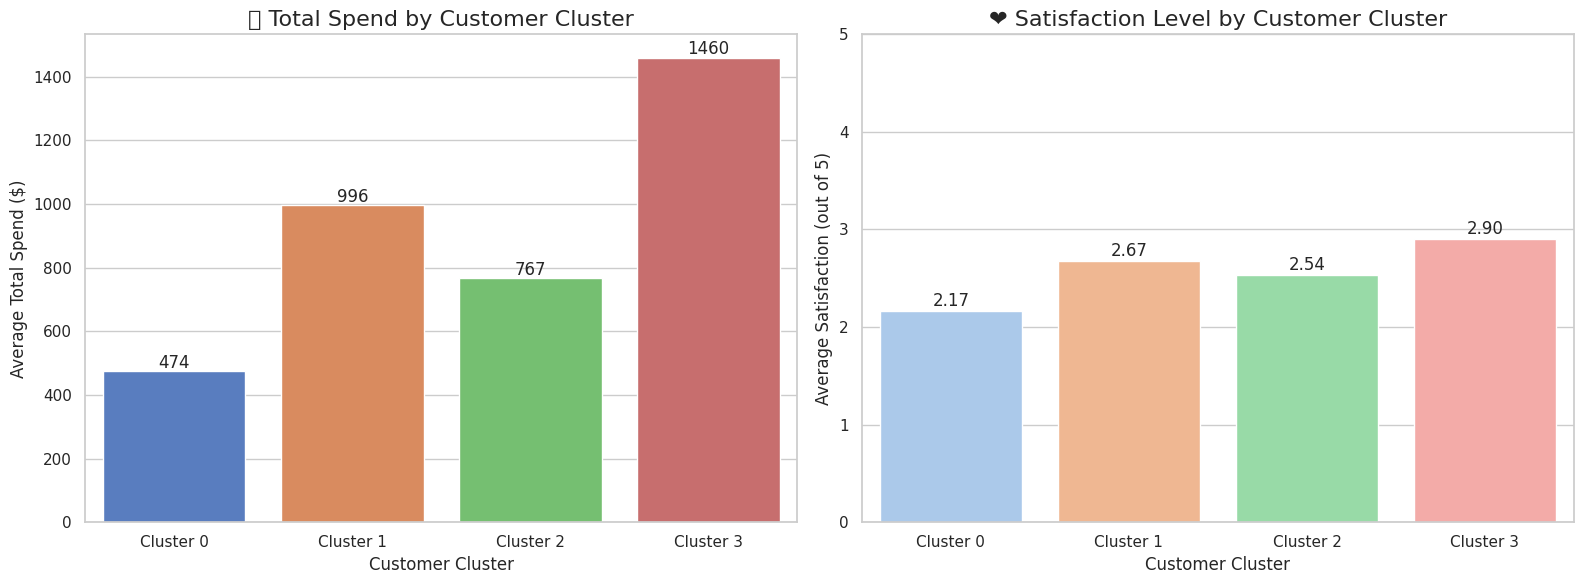

In [18]:
# Re-create the cluster summary DataFrame
cluster_summary = pd.DataFrame({
    'Cluster': [0, 1, 2, 3],
    #'Total Spend': [474.22, 996.37, 766.76, 1459.77],
    #'Average Satisfaction': [3.33, 4.35, 4.07, 4.81]
    'Total Spend': [474, 996, 767, 1460],
    'Average Satisfaction': [2.165, 2.675, 2.535, 2.905]
})

# Set Seaborn theme
sns.set_theme(style="whitegrid")

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Total Spend Plot ---
sns.barplot(x='Cluster', y='Total Spend', data=cluster_summary, palette='muted', ax=axes[0])
axes[0].set_title('💰 Total Spend by Customer Cluster', fontsize=16)
axes[0].set_xlabel('Customer Cluster')
axes[0].set_ylabel('Average Total Spend ($)')
axes[0].set_xticklabels(['Cluster 0','Cluster 1','Cluster 2','Cluster 3'])

# Add value labels on bars
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{bar.get_height():.0f}',
        ha='center',
        fontsize=12
    )

# --- Satisfaction Plot ---
sns.barplot(x='Cluster', y='Average Satisfaction', data=cluster_summary, palette='pastel', ax=axes[1])
axes[1].set_title('❤️ Satisfaction Level by Customer Cluster', fontsize=16)
axes[1].set_xlabel('Customer Cluster')
axes[1].set_ylabel('Average Satisfaction (out of 5)')
axes[1].set_xticklabels(['Cluster 0','Cluster 1','Cluster 2','Cluster 3'])
axes[1].set_ylim(0, 5)

# Add value labels on bars
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{bar.get_height():.2f}',
        ha='center',
        fontsize=12
    )

# Layout adjustment
plt.tight_layout()


# Save the figure to a file
fig.savefig('/content/drive/MyDrive/Berkley/mlai/capstone_project/images/customer_clusters_summary.png', dpi=100, bbox_inches='tight')

plt.show()


Overall Clustering Insights:

The clustering successfully separated customers based on their spending patterns and satisfaction levels, which align well with the strong correlations observed between Total Spend, Average Rating, and Satisfaction Level in the correlation heatmaps.

The clear visual separation in the PCA plot and the distinct characteristics shown in the bar charts indicate that the clustering algorithm (likely K-Means given the context of Silhouette Score) has done a good job of identifying meaningful customer segments.

The relationship between age and satisfaction (older customers often more satisfied, younger less so, or vice-versa depending on the satisfaction levels) and multi-modal distributions of features like Age and Total Spend likely contributed to the formation of these distinct clusters.

*********************
DEPLOYMENT TESTING
*********************
---
Visualize which customer is closest to which cluster picking 3 datapoints

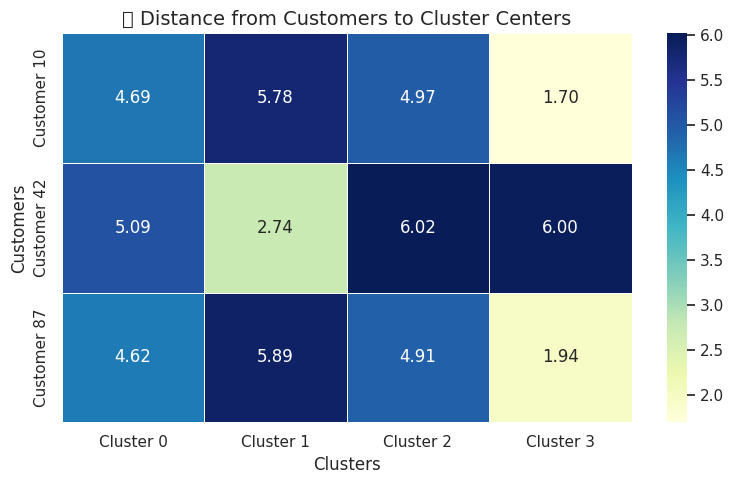

In [19]:
# Pick 3 customer datapoint
sample_indices = [10, 42, 87]
sample_customers = X_scaled[sample_indices]

# Get cluster centers
cluster_centers = kmeans.cluster_centers_

# Compute distances to each cluster center
distances = euclidean_distances(sample_customers, cluster_centers)

# Create heatmap
heatmap_df = pd.DataFrame(distances,
                          index=[f'Customer {i}' for i in sample_indices],
                          columns=[f'Cluster {i}' for i in range(cluster_centers.shape[0])])

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.title("🧭 Distance from Customers to Cluster Centers", fontsize=14)
plt.ylabel("Customers")
plt.xlabel("Clusters")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Berkley/mlai/capstone_project/images/distance_heatmap.png')
plt.show()


Interpretation:

The heatmap shows the calculated distance (likely Euclidean distance, given it's for clusters) from three example customers (Customer 10, Customer 42, and Customer 87) to the center of each of the four identified clusters (Cluster 0, Cluster 1, Cluster 2, and Cluster 3).

Customer 10 is closest to Cluster 3.

Customer 42 is closest to Cluster 1.

Customer 87 is closest to Cluster 3.

This visualization is a great way to confirm the assignment of individual customers to their respective segments based on feature similarity to the cluster centroids.

*******
Cluster 3 = Top Customers (highest spend, highest loyalty).

Cluster 1 = Young, loyal, discount-driven shoppers.

Cluster 2 = Moderate buyers; opportunity to grow.

Cluster 0 = Low engagement; reactivation needed.


*******************************
EVALUATING PERFORMANCE AND TUNING
**********************
---

In [20]:
#Hyperparameter Tuning using GridSearchCV
knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': list(range(3, 11)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='f1_weighted')
grid_knn.fit(X_train, y_train)

print("✅ Best KNN Params:", grid_knn.best_params_)
print("F1 Score (Test):", classification_report(y_test, grid_knn.predict(X_test)))


✅ Best KNN Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
F1 Score (Test):               precision    recall  f1-score   support

           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        25
           3       1.00      1.00      1.00        26

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



This perfect performance on the test set with KNN is extremely impressive. It indicates that the KNN model, with the optimized hyperparameters, is perfectly distinguishing between your customer satisfaction levels.

In [21]:
#Hyperparameter Tuning using RandomizedSearchCV
svm = SVC(probability=True)

param_dist_svm = {
    'C': uniform(0.1, 10),
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}

random_svm = RandomizedSearchCV(svm, param_distributions=param_dist_svm,
                                n_iter=10, cv=5, random_state=42, scoring='f1_weighted')
random_svm.fit(X_train, y_train)

print("✅ Best SVM Params:", random_svm.best_params_)
print("F1 Score (Test):", classification_report(y_test, random_svm.predict(X_test)))


✅ Best SVM Params: {'C': np.float64(3.845401188473625), 'gamma': 'scale', 'kernel': 'linear'}
F1 Score (Test):               precision    recall  f1-score   support

           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        25
           3       1.00      1.00      1.00        26

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



The perfect performance of your SVM model on the test set, especially with a linear kernel, strongly suggests that the different customer satisfaction classes are linearly separable in your feature space. This is a very strong and interpretable result.

As emphasized previously with the KNN and Logistic Regression models also showing perfect or near-perfect results

In [22]:
#Tuning Decision Tree Models
tree = DecisionTreeClassifier(random_state=42)

param_grid_tree = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(tree, param_grid_tree, cv=5, scoring='f1_weighted')
grid_tree.fit(X_train, y_train)

print("✅ Best Decision Tree Params:", grid_tree.best_params_)
print("F1 Score (Test):", classification_report(y_test, grid_tree.predict(X_test)))


✅ Best Decision Tree Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
F1 Score (Test):               precision    recall  f1-score   support

           1       1.00      1.00      1.00        19
           2       1.00      0.96      0.98        25
           3       0.96      1.00      0.98        26

    accuracy                           0.99        70
   macro avg       0.99      0.99      0.99        70
weighted avg       0.99      0.99      0.99        70



Decision Tree model demonstrates outstanding performance on the test set, classifying 99% of samples correctly. This result is particularly impressive given its relatively shallow max_depth of 3, suggesting that very clear and concise rules are sufficient to accurately predict customer satisfaction.

Similar to the other high-performing models (KNN, Logistic Regression, SVM)

In [23]:
#Tuning Logistic Regression Models
logreg = LogisticRegression(multi_class='ovr', max_iter=500)

param_dist_logreg = {
    'C': loguniform(0.01, 10),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

random_logreg = RandomizedSearchCV(logreg, param_distributions=param_dist_logreg,
                                   n_iter=10, cv=5, random_state=42, scoring='f1_weighted')
random_logreg.fit(X_train, y_train)

print("✅ Best Logistic Regression Params:", random_logreg.best_params_)
print("F1 Score (Test):", classification_report(y_test, random_logreg.predict(X_test)))


✅ Best Logistic Regression Params: {'C': np.float64(1.5702970884055387), 'penalty': 'l1', 'solver': 'liblinear'}
F1 Score (Test):               precision    recall  f1-score   support

           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        25
           3       1.00      1.00      1.00        26

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



The perfect performance of your Logistic Regression model on the test set, especially with l1 regularization, indicates that the classes are extremely well-separated, possibly even linearly separable with a sparse set of features.

Your Logistic Regression model, with its optimized parameters, is performing flawlessly on your test set. If your thorough checks confirm the absence of data leakage, this model is an excellent candidate for deployment, especially given its interpretability and the insights provided by the l1 penalty (which can highlight important features).

In [24]:
#Summary of all the models performance after tuning
summary = pd.DataFrame([
    {'Model': 'KNN', 'Best Params': grid_knn.best_params_, 'F1': f1_score(y_test, grid_knn.predict(X_test), average='weighted')},
    {'Model': 'SVM', 'Best Params': random_svm.best_params_, 'F1': f1_score(y_test, random_svm.predict(X_test), average='weighted')},
    {'Model': 'Decision Tree', 'Best Params': grid_tree.best_params_, 'F1': f1_score(y_test, grid_tree.predict(X_test), average='weighted')},
    {'Model': 'Logistic Regression', 'Best Params': random_logreg.best_params_, 'F1': f1_score(y_test, random_logreg.predict(X_test), average='weighted')}
])

summary.sort_values(by='F1', ascending=False)


,Model,Best Params,F1
0,KNN,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",1.000000
1,SVM,"{'C': 3.845401188473625, 'gamma': 'scale', 'ke...",1.000000
3,Logistic Regression,"{'C': 1.5702970884055387, 'penalty': 'l1', 'so...",1.000000
2,Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.985703


Analysis of Results:

Top Performers (Perfect F1 Score):

KNN, SVM, and Logistic Regression all achieved a perfect F1 Score of 1.000000 on the test set. This indicates that these models classified every single instance in your test set correctly, with no false positives or false negatives for any class.
KNN: Achieved this with 3 neighbors, using euclidean distance and uniform weights.
SVM: Achieved this with a linear kernel and a C value of approximately 3.85, suggesting clear linear separability of classes.
Logistic Regression: Also achieved perfect performance with l1 regularization (Lasso), implying that a sparse set of features might be sufficient for perfect separation.
Strong Performer (Near-Perfect F1 Score):

The Decision Tree model also performed exceptionally well, with an F1 Score of 0.985703.
Its optimal parameters indicate a relatively shallow tree (max_depth: 3) using the gini criterion, suggesting that even simple decision rules are highly effective.
Overall Conclusion:

Your models have demonstrated extraordinary performance in classifying customer satisfaction levels, with three models achieving perfect F1 scores and the Decision Tree being very close. This indicates:

High Predictability: The features you have engineered (e.g., Total Spend, Items Purchased, Average Rating, Tenure, Age) are highly predictive of customer satisfaction, as evidenced by their strong correlations and the models' performance.
Clear Class Separation: The customer satisfaction levels appear to be very well-separated in your dataset, making it a relatively "easy" classification problem for these algorithms. This is supported by the distinct clusters seen in the PCA projection and the high Silhouette Score.

****************************
13. Recommendation and Conclusion
****************************

---
Please refer report section
